## Objective
Analyze individual variables and understand dataset distributions before moving to relationships between variables.


In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
# Load Dataset

df = pd.read_excel("../data/online_retail_II.xlsx")

#Missing Customer IDs

df = df.dropna(subset=["Customer ID"])

#Duplicates

df = df.drop_duplicates()

# Total Amount Feature

df["TotalAmount"] = df["Quantity"] * df["Price"]

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (410763, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [3]:
# Dataset Overview

print("DATASET OVERVIEW")

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

DATASET OVERVIEW

Dataset Shape:
(410763, 9)

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
TotalAmount           float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 410763 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      410763 non-null  object        
 1   StockCode    410763 non-null  object        
 2   Description  410763 non-null  object        
 3   Quantity     410763 non-null  int64         
 4   InvoiceDate  410763 non-null  datetime64[ns]
 5   Price        410763 non-null  float64       
 6   Customer ID  410763 non-null  float64       
 7   Country      410763 non-null  object        
 8   TotalAmount  410763 non-nu

,Quantity,InvoiceDate,Price,Customer ID,TotalAmount
count,410763.000000,410763,410763.000000,410763.000000,410763.000000
mean,12.923735,2010-06-30 19:56:14.853674752,3.908358,15353.621857,20.242465
min,-9360.000000,2009-12-01 07:45:00,0.000000,12346.000000,-25111.090000
25%,2.000000,2010-03-26 09:46:00,1.250000,13979.000000,4.500000
50%,5.000000,2010-07-08 15:09:00,1.950000,15311.000000,11.800000
75%,12.000000,2010-10-14 12:32:00,3.750000,16797.000000,19.500000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,15818.400000
std,102.039550,NaN,71.714794,1681.657665,100.710825


## Dataset 
- Dataset contains transaction details such as product information, quantity, price, customer ID, and country.

- Most columns have the correct data type and can be used directly for analysis.

- Customer ID is available for customer-level analysis in later stages.

- Quantity and Price are the main numerical columns and will be used for further EDA.

- The dataset is large enough to identify customer purchasing patterns.

- After cleaning, the data is ready for exploratory analysis.

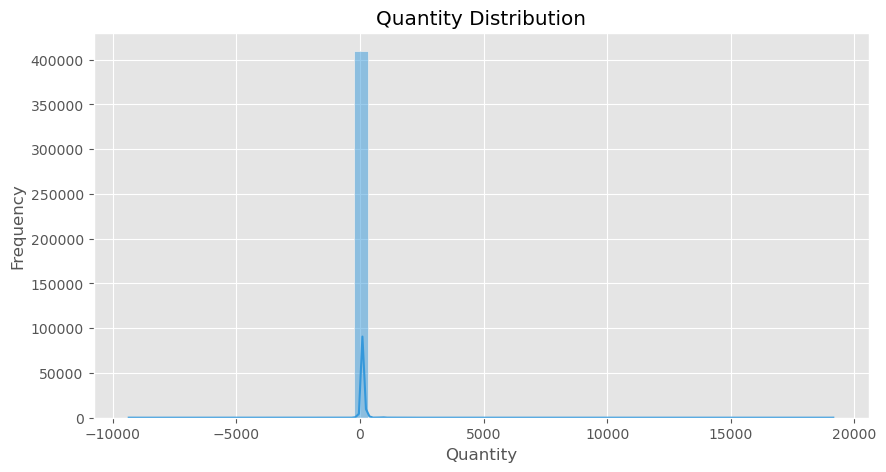

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Quantity"],
    bins=50,
    kde=True,
    color="#3498DB"
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

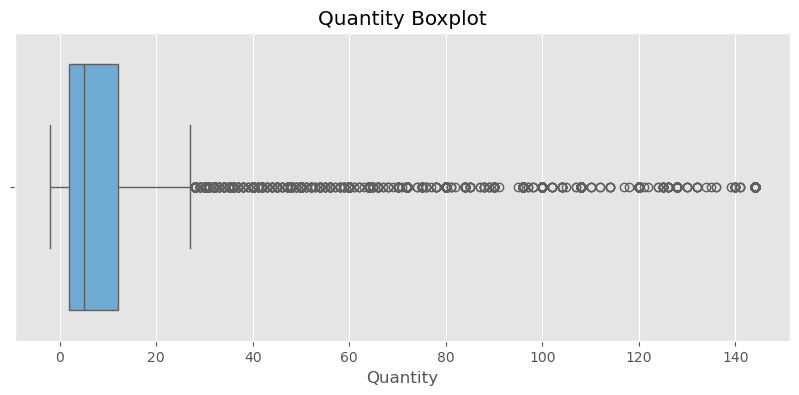

In [5]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df[df["Quantity"].between(
        df["Quantity"].quantile(0.01),
        df["Quantity"].quantile(0.99)
    )]["Quantity"],
    color="#5DADE2"
)

plt.title("Quantity Boxplot")

plt.show()

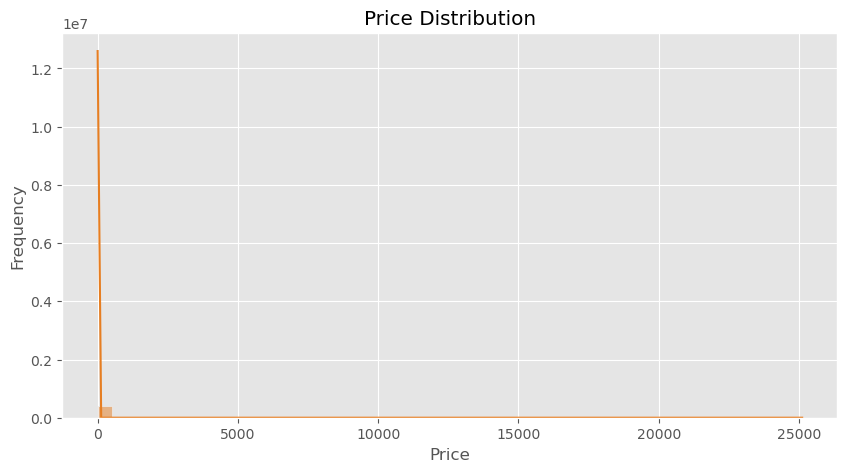

In [6]:
# Price Distribution Analysis

plt.figure(figsize=(10,5))

sns.histplot(
    df["Price"],
    bins=50,
    kde=True,
    color="#E67E22"
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

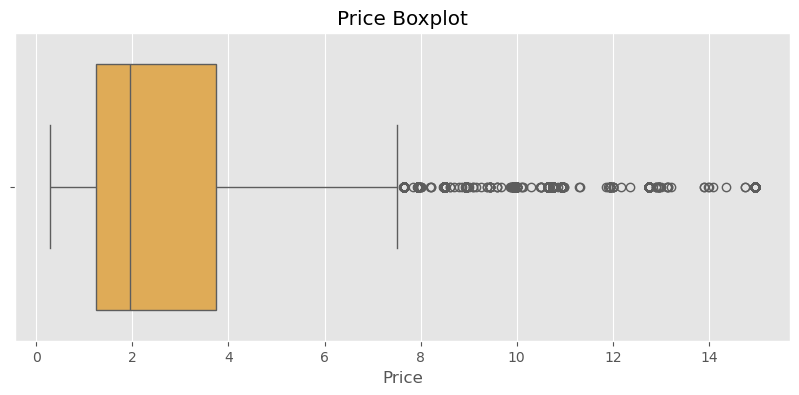

In [7]:
# Price Boxplot

plt.figure(figsize=(10,4))

sns.boxplot(
    x=df[df["Price"].between(
        df["Price"].quantile(0.01),
        df["Price"].quantile(0.99)
    )]["Price"],
    color="#F5B041"
)

plt.title("Price Boxplot")

plt.show()

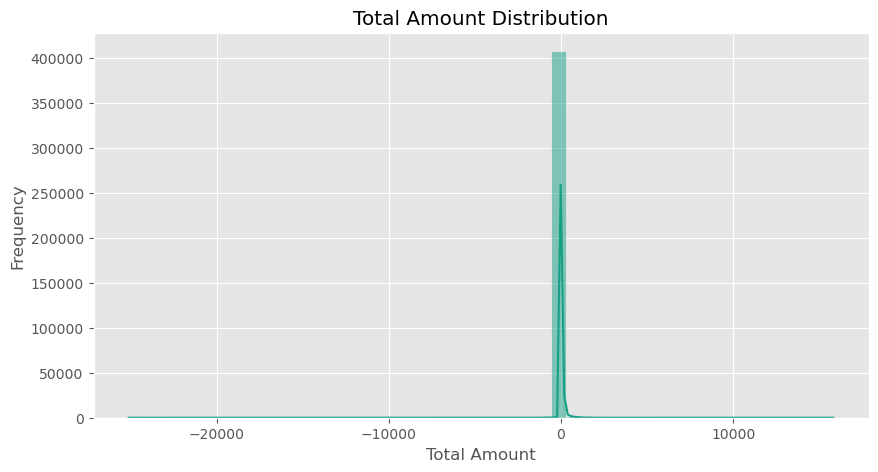

In [8]:
# Total Amount Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df["TotalAmount"],
    bins=50,
    kde=True,
    color="#16A085"
)

plt.title("Total Amount Distribution")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

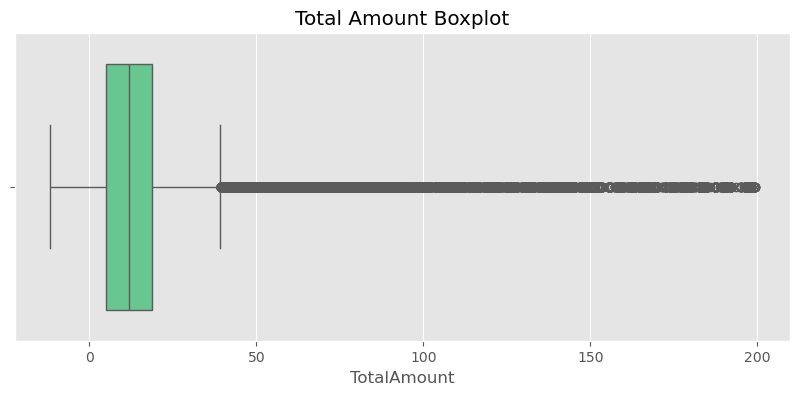

In [9]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df[df["TotalAmount"].between(
        df["TotalAmount"].quantile(0.01),
        df["TotalAmount"].quantile(0.99)
    )]["TotalAmount"],
    color="#58D68D"
)

plt.title("Total Amount Boxplot")

plt.show()

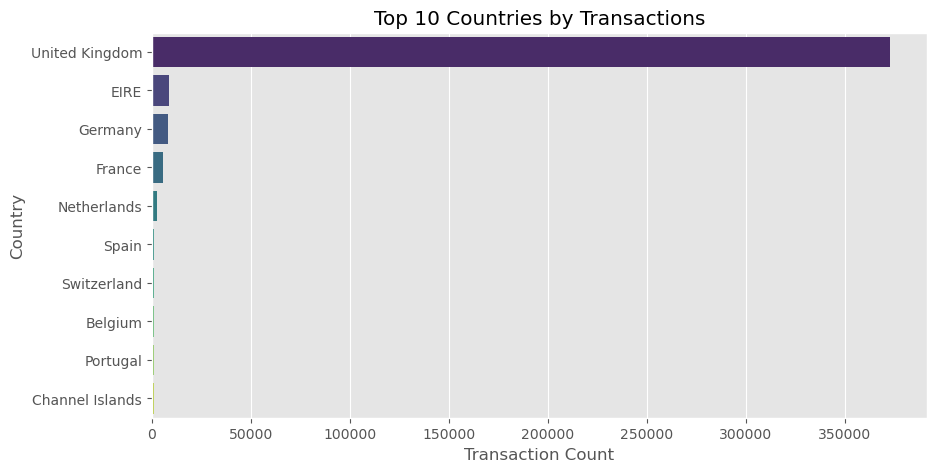

In [10]:
# Country Distribution

top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Countries by Transactions")
plt.xlabel("Transaction Count")
plt.ylabel("Country")

plt.show()

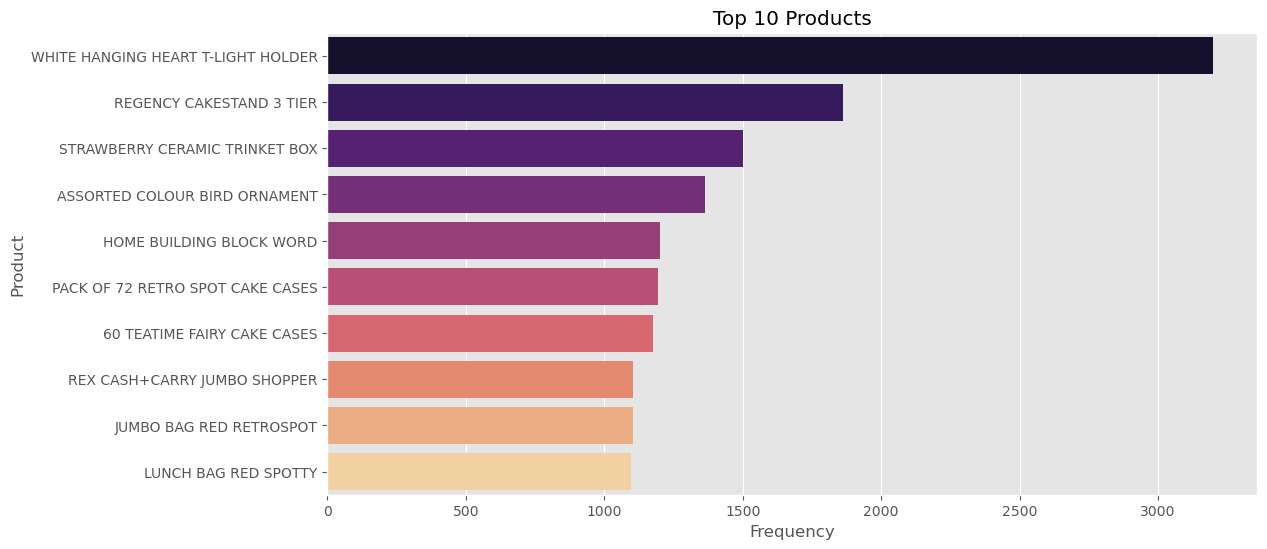

In [11]:
top_products = df["Description"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Products")
plt.xlabel("Frequency")
plt.ylabel("Product")

plt.show()

In [12]:
df[["Quantity","Price","TotalAmount"]].describe()

,Quantity,Price,TotalAmount
count,410763.000000,410763.000000,410763.000000
mean,12.923735,3.908358,20.242465
std,102.039550,71.714794,100.710825
min,-9360.000000,0.000000,-25111.090000
25%,2.000000,1.250000,4.500000
50%,5.000000,1.950000,11.800000
75%,12.000000,3.750000,19.500000
max,19152.000000,25111.090000,15818.400000


In [13]:
df[["Quantity","Price","TotalAmount"]].skew() #High skewness values indicate non-normal distributions.

Quantity        62.215921
Price          182.465816
TotalAmount    -30.783973
dtype: float64

In [14]:
df[["Quantity","Price","TotalAmount"]].kurt()  #Kurtosis values suggest the presence of extreme observations and heavy tails.

Quantity        8078.693915
Price          46656.238721
TotalAmount    13815.796569
dtype: float64

## Findings

- Quantity values are concentrated within a lower range, while a limited number of transactions contain exceptionally large quantities.

- Price distribution is uneven, with most products having relatively low prices and a small number of observations showing very high values.

- TotalAmount varies considerably across transactions, reflecting differences in customer purchasing behavior and order sizes.

- The majority of transactions originate from the United Kingdom, indicating a strong concentration of activity within a single market.

- Product frequency analysis shows that a small group of products appears significantly more often than others.

- Summary statistics reveal large differences between minimum, maximum, and average values, suggesting the presence of extreme observations.

- Skewness and kurtosis measures indicate that the numerical variables do not follow a normal distribution.

- Boxplots confirm the existence of outliers in Quantity, Price, and TotalAmount.

## Conclusion

Univariate analysis was conducted on the primary variables of the dataset using summary statistics, distribution plots, frequency analysis, and boxplots.

The analysis highlights the presence of skewed distributions, extreme values, and uneven transaction patterns across products and countries. These findings provide a better understanding of the underlying structure of the dataset and help identify areas that require attention during further analysis.

The dataset is now prepared for the next stage of Exploratory Data Analysis, where relationships between variables and customer purchasing patterns will be examined.

### Correlation Analysis

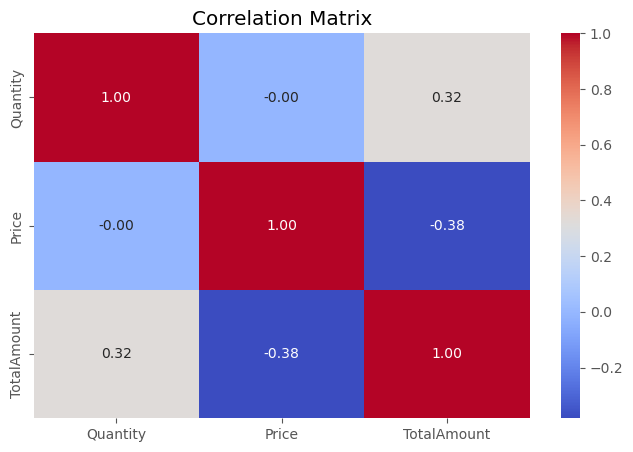

In [15]:
# Correlation Matrix

corr_columns = ["Quantity", "Price", "TotalAmount"]

correlation = df[corr_columns].corr()

plt.figure(figsize=(8,5))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

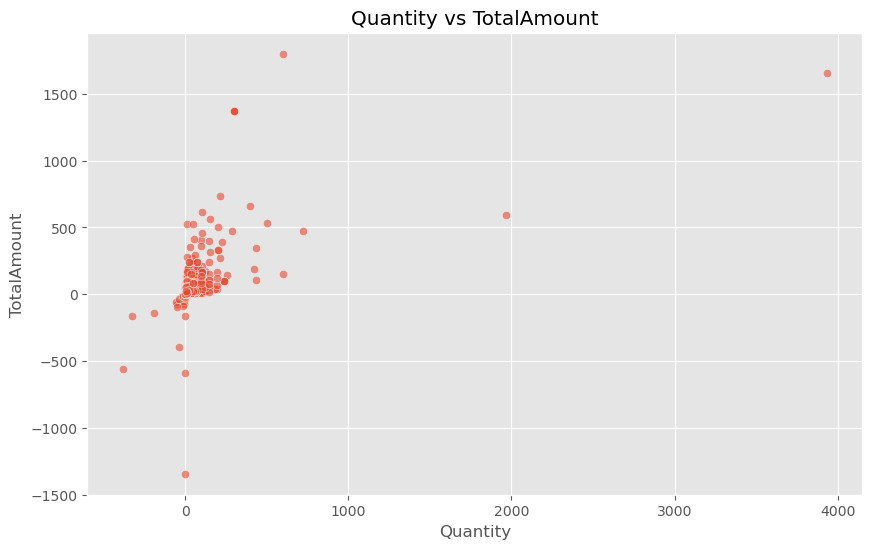

In [16]:
# Quantity vs TotalAmount

sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="Quantity",
    y="TotalAmount",
    alpha=0.6
)

plt.title("Quantity vs TotalAmount")
plt.show()

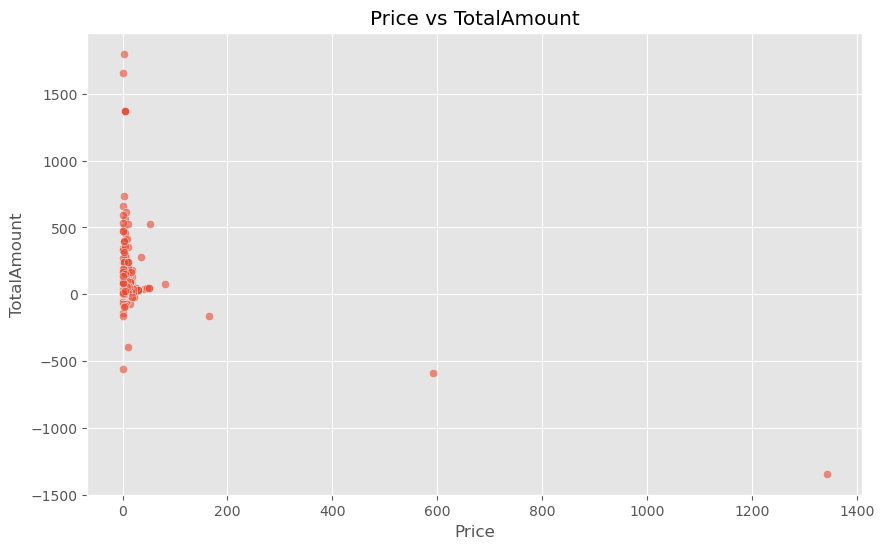

In [17]:
# Price vs TotalAmount

sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="Price",
    y="TotalAmount",
    alpha=0.6
)

plt.title("Price vs TotalAmount")
plt.show()

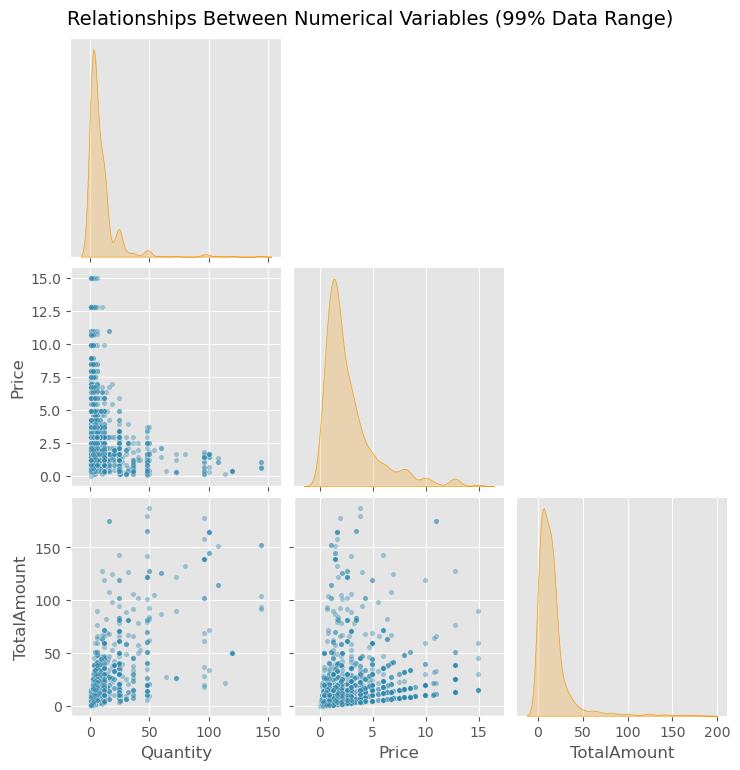

In [27]:
#pair plot
pair_df = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
].copy()

pair_df = pair_df[
    (pair_df["Quantity"] <= pair_df["Quantity"].quantile(0.99)) &
    (pair_df["Price"] <= pair_df["Price"].quantile(0.99)) &
    (pair_df["TotalAmount"] <= pair_df["TotalAmount"].quantile(0.99))
]

pair_df = pair_df.sample(3000, random_state=42)

sns.pairplot(
    pair_df[["Quantity","Price","TotalAmount"]],
    diag_kind="kde",
    corner=True,
    plot_kws={
        "alpha":0.4,
        "s":15,
        "color":"#2E86AB"
    },
    diag_kws={
        "fill":True,
        "color":"#F39C12"
    }
)

plt.suptitle(
    "Relationships Between Numerical Variables (99% Data Range)",
    y=1.02,
    fontsize=14
)

plt.show()

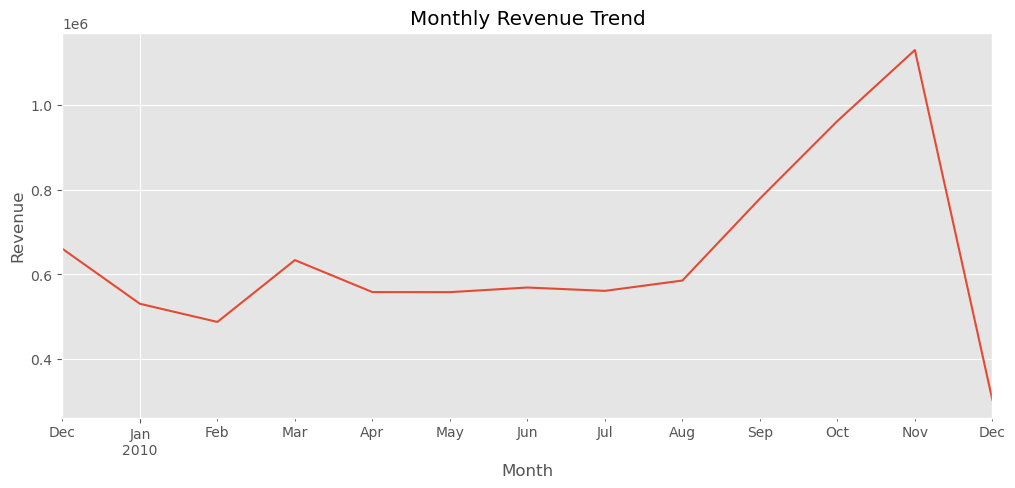

In [18]:
# Create Month Column

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["TotalAmount"]
    .sum()
)

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

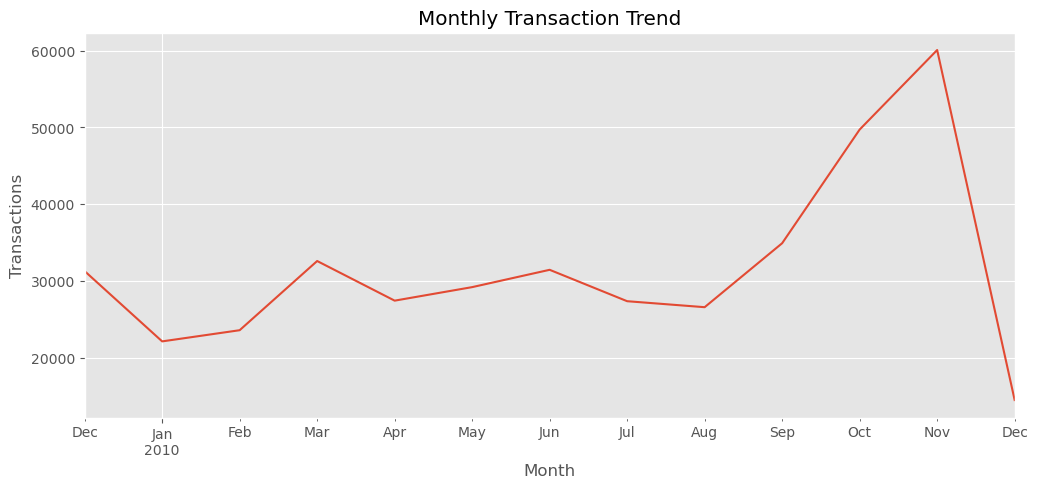

In [19]:
# Monthly Transactions

monthly_orders = (
    df.groupby("Month")["Invoice"]
    .count()
)

plt.figure(figsize=(12,5))

monthly_orders.plot()

plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Transactions")

plt.show()

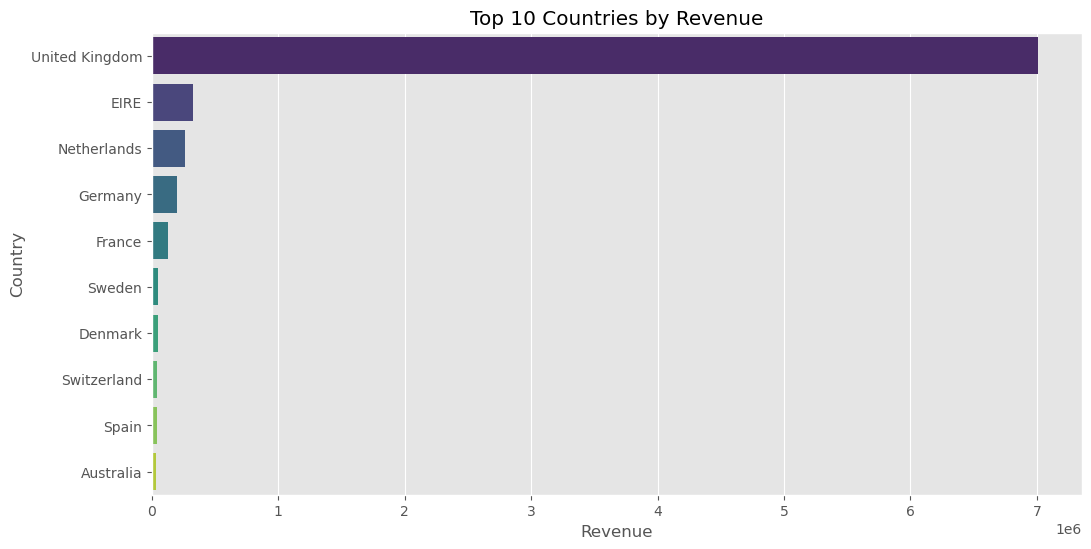

In [20]:
# Revenue by Country

country_sales = (
    df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index,
    hue=country_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

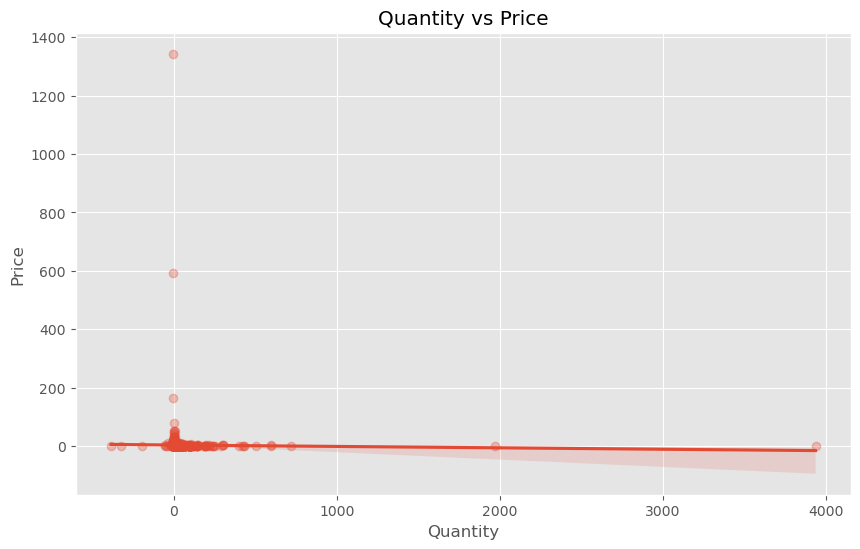

In [21]:
# Quantity vs Price

sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10,6))

sns.regplot(
    data=sample_df,
    x="Quantity",
    y="Price",
    scatter_kws={"alpha":0.3}
)

plt.title("Quantity vs Price")
plt.show()

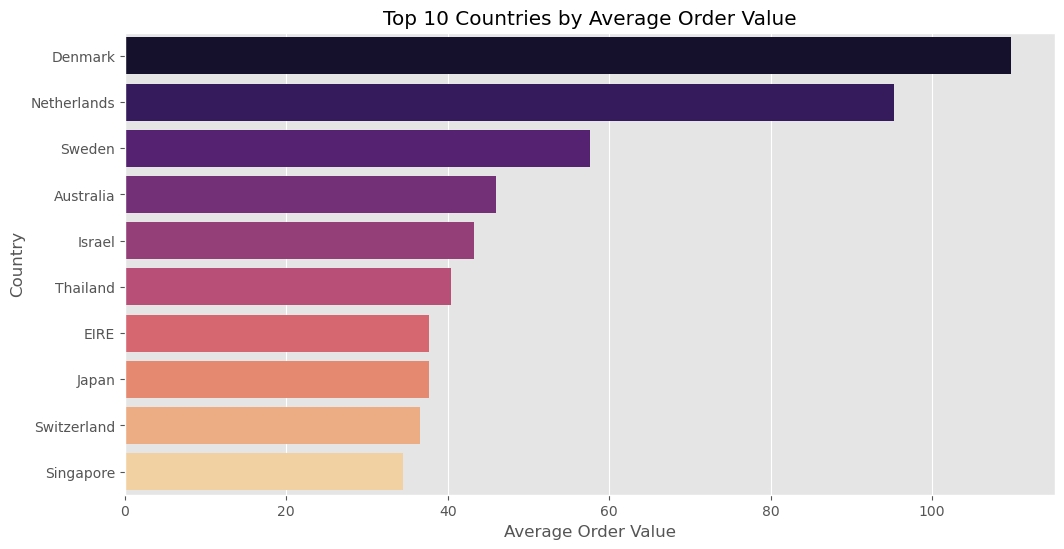

In [22]:
# Average Order Value by Country

country_aov = (
    df.groupby("Country")["TotalAmount"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_aov.values,
    y=country_aov.index,
    hue=country_aov.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Countries by Average Order Value")
plt.xlabel("Average Order Value")

plt.show()

In [24]:
# Country contribution percentage

country_revenue = df.groupby("Country")["TotalAmount"].sum()

country_percentage = (
    country_revenue /
    country_revenue.sum() * 100
).sort_values(ascending=False)

country_percentage.head(10)

Country
United Kingdom    84.256345
EIRE               3.947564
Netherlands        3.173378
Germany            2.356270
France             1.559444
Sweden             0.611389
Denmark            0.564928
Switzerland        0.521277
Spain              0.445614
Australia          0.361423
Name: TotalAmount, dtype: float64

## Findings

- Revenue is heavily concentrated in the United Kingdom, with limited contribution from other countries.

- Monthly sales trends show noticeable fluctuations, indicating changes in purchasing activity over time.

- Quantity and TotalAmount exhibit a positive relationship, with larger purchases generally generating higher revenue.

- Revenue distribution across countries is highly uneven, suggesting dependence on a small number of markets.

- Several high-value transactions are visible in the scatter plots, highlighting the presence of extreme purchasing behavior.

## Conclusion

Correlation, time-series and geographic analyses provided a clearer understanding of customer purchasing behavior and revenue patterns. The results highlight market concentration, temporal variations in sales activity and key relationships between business variables. These insights will support feature engineering and customer segmentation in the next stage of the project.